<a href="https://colab.research.google.com/github/Sal310/KVScope/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KVScope — KV Cache Optimization Benchmarks

A unified framework comparing the three KV-cache optimization categories
identified in the literature review on a shared workload:
**eviction** (sliding window, StreamingLLM, H2O, SnapKV), **quantization**
(KIVI int8 / 4-bit / 2-bit; GPTQ weight quantization measured externally),
and **architectural sharing** (MQA/GQA via each model's native config plus
zero-shot mean-pool surgery).

The novelty contribution is a custom **fused Triton kernel** that composes
two of these categories at the kernel level — sliding-window eviction with
in-kernel int8 dequantization in a single pass.

> **Refactored from :** the 133-cell monolith was split into four importable
> modules (`benchmark_utils.py`, `policies.py`, `quantization.py`,
> `kernels.py`). Every section in this notebook is self-contained — it reloads
> its own model, runs its own sweep, writes its own CSV, and frees GPU memory
> before the next section. You can re-run any section without re-running
> everything above it.

**Coursework connections:**
- **HW1** (real-time GPU monitoring + per-layer profiling): Section 13 traces
  KV-cache memory and runs `torch.profiler` on a decode pass.
- **HW2** (CUDA thread/block model): Section 5 & 12 kernels use the same
  block-grid programming model.
- **HW3** (JIT compilation + operator fusion): Section 12 measures the fused
  kernel — kernel launch counts, memory bandwidth reduction, theoretical
  vs actual speedup.


## 1. Setup

Upload `benchmark_utils.py`, `policies.py`, `quantization.py`, and
`kernels.py` to the Colab runtime alongside this notebook before running.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now that Drive is mounted, you can copy the necessary Python files from your Drive to the current content directory. For example, if your files are in a folder named `kvscope_files` in your Google Drive, you would run:

```bash
!cp /content/drive/MyDrive/cs790/benchmark_utils.py /content/
!cp /content/drive/MyDrive/kvscope_files/policies.py /content/
!cp /content/drive/MyDrive/kvscope_files/quantization.py /content/
!cp /content/drive/MyDrive/kvscope_files/kernels.py /content/
```

Remember to replace `kvscope_files` with the actual path to your files in Google Drive.

In [ ]:
!pip install transformers matplotlib datasets triton -q

import random, numpy as np, torch, triton, transformers

torch.manual_seed(42); random.seed(42); np.random.seed(42)

print(f"GPU:          {torch.cuda.get_device_name(0)}")
print(f"PyTorch:      {torch.__version__} (CUDA {torch.version.cuda})")
print(f"Triton:       {triton.__version__}")
print(f"Transformers: {transformers.__version__}")

GPU:          NVIDIA A100-SXM4-40GB
PyTorch:      2.10.0+cu128 (CUDA 12.8)
Triton:       3.6.0
Transformers: 5.0.0


In [ ]:
!ls -F /content/drive/MyDrive/cs790/

analysis.ipynb	    kernels.py	 quantization.py
benchmark_utils.py  policies.py  SmolLM2-1.7B-GPTQ-Int4/


In [ ]:
!cp /content/drive/MyDrive/cs790/benchmark_utils.py /content/
!cp /content/drive/MyDrive/cs790/policies.py /content/
!cp /content/drive/MyDrive/cs790/quantization.py /content/
!cp /content/drive/MyDrive/cs790/kernels.py /content/

print('Files copied to /content/')
!ls -F /content/

Files copied to /content/
benchmark_utils.py  kernels.py	 quantization.py
drive/		    policies.py  sample_data/


Now that the files have been copied to the `/content/` directory, you can re-run the cell that was previously failing (cell `f500af3f`). It should now successfully import all the required modules.

In [ ]:
print('Listing files in current directory:')
!ls -F

Listing files in current directory:
benchmark_utils.py  kernels.py	 quantization.py
drive/		    policies.py  sample_data/


In [ ]:
import os, math, time, importlib
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, DynamicCache

# Verify the four project modules are on the Colab filesystem
for f in ("benchmark_utils.py", "policies.py", "quantization.py", "kernels.py"):
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Required module {f} not found. Upload all four project "
            f"modules to the Colab runtime alongside this notebook."
        )

# Hot-reload so editing a .py file then re-running this cell picks up changes
import benchmark_utils, policies, quantization, kernels
for m in (benchmark_utils, policies, quantization, kernels):
    importlib.reload(m)

from benchmark_utils import (benchmark, cache_bytes, prefill_full,
                             decode_bench, perplexity, count_cuda_kernels,
                             gpu_time, gpu_mem)
from policies import (KVPolicy, kv_policy, dispatch_policy,
                      full_causal_attention, sliding_window_attention,
                      streaming_attention, h2o_attention,
                      evict_cache, snapkv_prune, h2o_prune,
                      make_mask, make_window_mask, snapkv_mask, h2o_mask,
                      convert_kv_heads_via_meanpool)
from quantization import (quantize_per_channel_nbit, quant_int8,
                          kivi_hooks, kivi_perplexity_nbit)
from kernels import (triton_sliding_window,
                     fused_swa_dequant, unfused_int8_path)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
PyTorch: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-40GB


## 2. Configuration

All experiment-wide constants live here. Re-run this cell after editing to
propagate changes to the rest of the notebook.

In [ ]:
# Models for the per-model sweeps. Same two as v51 — one MHA, one GQA.
SWEEP_MODELS = [
    ("SmolLM2-1.7B", "HuggingFaceTB/SmolLM2-1.7B", "MHA G=1 (1.7B)"),
    ("Qwen2-0.5B",   "Qwen/Qwen2-0.5B",            "GQA G=7 (0.5B)"),
]
EVAL_MODELS = [(mid, mname) for mname, mid, _arch in SWEEP_MODELS]

# Eviction sweep parameters (§6, §7)
PROMPT_LEN, NEW_TOK, BUDGET, SINK = 1024, 128, 256, 4
PROMPT_TEXT = (
    "The Project Gutenberg eBook of Pride and Prejudice, by Jane Austen. "
    "It is a truth universally acknowledged, that a single man in possession "
    "of a good fortune, must be in want of a wife. "
) * 16

# Perplexity scoring parameters (§6, §8, §10)
T_LEN, P_EVAL, OW = 2048, 1024, 32

# Sequence-length sweep parameters (§7, §8b)
SWEEP_LENS = [512, 1024, 2048, 4096]
SWEEP_NEW = 64

# Load WikiText-2 once. Cached on disk after first run.
try:
    from datasets import load_dataset
    _ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    LONG_TEXT = "\n\n".join(t for t in _ds["text"] if t.strip())
    print(f"WikiText-2 loaded: {len(LONG_TEXT):,} chars")
except Exception as e:
    LONG_TEXT = "The Project Gutenberg eBook of Pride and Prejudice. " * 500
    print(f"WikiText-2 unavailable ({e}); using Gutenberg fallback (ppl will be unreliable)")

CONFIGS = {
    "SmolLM2-1.7B": (1, 32, 64),
    "Qwen2-0.5B":   (1, 2,  64),
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

WikiText-2 loaded: 1,291,402 chars


## 3. DSL Unit Tests

Verify the `@kv_policy` decorator + `dispatch_policy()` machinery routes
to the right reference attention implementation. These are pure-PyTorch
sanity checks — no models loaded.

In [ ]:
torch.manual_seed(42)
B, H, T, D = 1, 4, 64, 64
q, k, v = (torch.randn(B, H, T, D, device=device) for _ in range(3))

@kv_policy(strategy="sliding_window", window_size=T)
def p_full(): pass
@kv_policy(strategy="sliding_window", window_size=8)
def p_small(): pass
@kv_policy(strategy="streaming", window_size=8, sink_size=4)
def p_stream(): pass
@kv_policy(strategy="h2o", budget=16)
def p_h2o(): pass

def diff(a, b): return (a - b).abs().max().item()

tests = [
    ("sliding W=T  == full",      diff(full_causal_attention(q,k,v), sliding_window_attention(q,k,v,T)),    "<", 1e-4),
    ("sliding W=8  != full",      diff(full_causal_attention(q,k,v), sliding_window_attention(q,k,v,8)),    ">", 1e-3),
    ("streaming    != full",      diff(full_causal_attention(q,k,v), streaming_attention(q,k,v,8,4)),       ">", 1e-3),
    ("streaming    != sliding",   diff(sliding_window_attention(q,k,v,8), streaming_attention(q,k,v,8,4)),  ">", 1e-6),
    ("h2o b=T      == full",      diff(full_causal_attention(q,k,v), h2o_attention(q,k,v,T)),               "<", 1e-3),
    ("h2o b=16     != full",      diff(full_causal_attention(q,k,v), h2o_attention(q,k,v,16)),              ">", 1e-3),
    ("dispatch sliding",          diff(dispatch_policy(p_full.policy)(q,k,v),    full_causal_attention(q,k,v)),  "<", 1e-4),
    ("dispatch streaming",        diff(dispatch_policy(p_stream.policy)(q,k,v),  streaming_attention(q,k,v,8,4)), "<", 1e-6),
    ("dispatch h2o",              diff(dispatch_policy(p_h2o.policy)(q,k,v),     h2o_attention(q,k,v,16)),    "<", 1e-6),
]
ok = all((d < t) if op == "<" else (d > t) for _, d, op, t in tests)
for name, d, op, t in tests:
    p = (d < t) if op == "<" else (d > t)
    print(f"{'PASS' if p else 'FAIL'} | {name:30s} | diff={d:.2e}")
assert ok, "DSL tests failed"


PASS | sliding W=T  == full           | diff=0.00e+00
PASS | sliding W=8  != full           | diff=2.23e+00
PASS | streaming    != full           | diff=3.35e+00
PASS | streaming    != sliding        | diff=3.35e+00
PASS | h2o b=T      == full           | diff=0.00e+00
PASS | h2o b=16     != full           | diff=2.25e+00
PASS | dispatch sliding               | diff=0.00e+00
PASS | dispatch streaming             | diff=0.00e+00
PASS | dispatch h2o                   | diff=0.00e+00


## 4. Baseline

`model.generate()` throughput on both models at a few prompt lengths.

> Throughput here is the overhead floor — Python `generate()` loop dominates
> over GPU compute / HBM bandwidth at batch=1 with short decodes. Treat
> downstream §6 / §7 / §8 throughput numbers as differential vs this floor,
> not absolute speedups.

In [ ]:
baseline_rows = []
for model_name, model_id in [(m, mid) for m, mid, _ in SWEEP_MODELS]:
    print(f"Loading {model_name}...")
    tok = AutoTokenizer.from_pretrained(model_id)
    m = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.float16, attn_implementation="eager",
    ).to(device).eval()

    for plen in [64, 128, 256, 512]:
        ids = tok.encode("The quick brown fox", return_tensors="pt")
        ids = ids.repeat(1, (plen // ids.shape[1]) + 1)[:, :plen].to(device)
        attn_mask = torch.ones_like(ids)
        with torch.no_grad():
            _ = m.generate(ids, attention_mask=attn_mask, max_new_tokens=10,
                           pad_token_id=tok.eos_token_id)
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()

        t0 = time.perf_counter()
        with torch.no_grad():
            m.generate(ids, attention_mask=attn_mask, max_new_tokens=50,
                       pad_token_id=tok.eos_token_id, use_cache=True)
        torch.cuda.synchronize()
        dt = time.perf_counter() - t0

        baseline_rows.append({
            "model": model_name, "prompt_len": plen,
            "peak_GB":   round(torch.cuda.max_memory_allocated() / 1e9, 3),
            "latency_ms": round(dt * 1000, 1),
            "tok_per_s":  round(50 / dt, 1),
        })
        print(f"  prompt={plen:3d} | peak={baseline_rows[-1]['peak_GB']}GB"
              f" | {baseline_rows[-1]['tok_per_s']} tok/s")
    del m; torch.cuda.empty_cache()

df_baseline = pd.DataFrame(baseline_rows)
df_baseline.to_csv("results_baseline.csv", index=False)
print()
print(df_baseline.to_string(index=False))


Loading SmolLM2-1.7B...


config.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

  prompt= 64 | peak=1.01GB | 28.0 tok/s
  prompt=128 | peak=1.014GB | 28.7 tok/s
  prompt=256 | peak=1.024GB | 28.3 tok/s
  prompt=512 | peak=1.048GB | 28.3 tok/s

       model  prompt_len  peak_GB  latency_ms  tok_per_s
SmolLM2-1.7B          64    3.454      1623.5       30.8
SmolLM2-1.7B         128    3.467      1627.5       30.7
SmolLM2-1.7B         256    3.503      1579.2       31.7
SmolLM2-1.7B         512    3.608      1607.4       31.1
  Qwen2-0.5B          64    1.010      1786.6       28.0
  Qwen2-0.5B         128    1.014      1742.0       28.7
  Qwen2-0.5B         256    1.024      1766.2       28.3
  Qwen2-0.5B         512    1.048      1765.4       28.3


### 5. Triton sliding-window vs full-attention reference

Kernel-level microbenchmark using randomized Q/K/V tensors at shapes
representative of decode-time KV access patterns. Sanity check that the
kernel actually saves work — sliding-window time should fall sharply
when W << N because most of the attention matrix is masked.

End-to-end integration into a HuggingFace attention module is left as
future work; throughput measurements here are isolated kernel timings,
not full-model inference speedups.

In [ ]:
SEQ_LENS = [512, 1024, 2048, 4096]
W = 128

triton_rows = []
for mname, (B, H, D) in CONFIGS.items():
    print(f"\n{mname}")
    for N in SEQ_LENS:
        Q = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
        K = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
        V = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
        t_full, _   = benchmark(lambda: full_causal_attention(Q, K, V))
        t_triton, _ = benchmark(lambda: triton_sliding_window(Q, K, V, W))
        triton_rows.append({"model": mname, "seq_len": N, "window": W,
                            "full_ms": round(t_full, 3),
                            "triton_ms": round(t_triton, 3),
                            "speedup": round(t_full / t_triton, 2),
                            "attn_computed_pct": round(W / N * 100, 1)})
        print(f"  N={N:5d} | full={t_full:7.2f}ms | triton={t_triton:7.2f}ms"
              f" | {t_full/t_triton:.2f}x | attn computed: {W/N*100:.1f}%")

pd.DataFrame(triton_rows).to_csv("results_triton_perf.csv", index=False)



SmolLM2-1.7B
  N=  512 | full=   0.31ms | triton=   0.07ms | 4.35x | attn computed: 25.0%
  N= 1024 | full=   0.83ms | triton=   0.08ms | 9.82x | attn computed: 12.5%
  N= 2048 | full=   3.02ms | triton=   0.10ms | 30.48x | attn computed: 6.2%
  N= 4096 | full=  11.35ms | triton=   0.13ms | 84.92x | attn computed: 3.1%

Qwen2-0.5B
  N=  512 | full=   0.28ms | triton=   0.06ms | 4.52x | attn computed: 25.0%
  N= 1024 | full=   0.28ms | triton=   0.06ms | 4.57x | attn computed: 12.5%
  N= 2048 | full=   0.31ms | triton=   0.06ms | 4.98x | attn computed: 6.2%
  N= 4096 | full=   0.87ms | triton=   0.11ms | 8.00x | attn computed: 3.1%


## 6. Eviction Policies

Two measurements per policy:
- **Cache footprint + throughput** — real decode using `decode_bench`
- **Perplexity** — masked forward pass via `policies.{make_window_mask, snapkv_mask, h2o_mask}` + `perplexity`

In [ ]:
# ── 6a. Cache footprint + throughput ─────────────────────────────────────
eviction_rows_all = []
for model_path, model_tag in EVAL_MODELS:
    print(f"\n=== Eviction sweep on {model_tag} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path, torch_dtype=torch.float16, attn_implementation="eager",
    ).to(device).eval()

    # Build prompt of exactly PROMPT_LEN tokens
    ids = tokenizer.encode(PROMPT_TEXT, return_tensors="pt")
    mult = 1
    while ids.shape[1] < PROMPT_LEN:
        mult += 1
        ids = tokenizer.encode(PROMPT_TEXT * mult, return_tensors="pt")
    prompt_ids = ids[:, :PROMPT_LEN].to(device)
    print(f"  prompt length: {prompt_ids.shape[1]} tokens, budget={BUDGET}")

    def prefill_evict(sink, win):
        c, last = prefill_full(model, prompt_ids); evict_cache(c, sink, win); return c, last

    setups = [
        ("full",                                lambda: prefill_full(model, prompt_ids)),
        (f"sliding(W={BUDGET})",                lambda: prefill_evict(0, BUDGET)),
        (f"streaming(s={SINK},W={BUDGET-SINK})", lambda: prefill_evict(SINK, BUDGET - SINK)),
        (f"snapkv(b={BUDGET})",                 lambda: snapkv_prune(model, prompt_ids, BUDGET)),
        (f"h2o(b={BUDGET})",                    lambda: h2o_prune(model, prompt_ids, BUDGET)),
    ]
    for name, setup in setups:
        cache, last = setup()
        r = {"model": model_tag, "category": "eviction", "policy": name,
             **decode_bench(model, cache, last, NEW_TOK)}
        eviction_rows_all.append(r)
        print(f"  {name:32s} | cache={r['cache_MB']:6.2f}MB | "
              f"peak={r['peak_GB']:.2f}GB | {r['tok_per_s']:5.1f} tok/s")
    del model; torch.cuda.empty_cache()

df_eviction = pd.DataFrame(eviction_rows_all)
df_eviction.to_csv("results_eviction.csv", index=False)
print(f"\n{len(df_eviction)} rows -> results_eviction.csv")



=== Eviction sweep on SmolLM2-1.7B ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

  prompt length: 1024 tokens, budget=256
  full                             | cache=226.49MB | peak=3.77GB |  31.7 tok/s
  sliding(W=256)                   | cache= 75.50MB | peak=3.74GB |  32.0 tok/s
  streaming(s=4,W=252)             | cache= 75.50MB | peak=3.62GB |  31.9 tok/s
  snapkv(b=256)                    | cache= 75.50MB | peak=3.62GB |  32.0 tok/s
  h2o(b=256)                       | cache= 75.50MB | peak=3.62GB |  31.5 tok/s

=== Eviction sweep on Qwen2-0.5B ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  prompt length: 1024 tokens, budget=256
  full                             | cache= 14.16MB | peak=2.14GB |  29.3 tok/s
  sliding(W=256)                   | cache=  4.72MB | peak=2.14GB |  29.1 tok/s
  streaming(s=4,W=252)             | cache=  4.72MB | peak=2.13GB |  29.1 tok/s
  snapkv(b=256)                    | cache=  4.72MB | peak=2.13GB |  28.9 tok/s
  h2o(b=256)                       | cache=  4.72MB | peak=2.13GB |  29.0 tok/s

10 rows -> results_eviction.csv


In [ ]:
# ── 6b. Perplexity for each policy ───────────────────────────────────────
quality_rows_all = []
for model_path, model_tag in EVAL_MODELS:
    print(f"\n=== Perplexity sweep on {model_tag} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path, torch_dtype=torch.float16, attn_implementation="eager",
    ).to(device).eval()

    ids_eval = tokenizer.encode(LONG_TEXT, return_tensors="pt")[:, :T_LEN].to(device)
    T = ids_eval.shape[1]

    configs = [
        ("full",                                 lambda: None),
        (f"sliding(W={BUDGET})",                 lambda: make_window_mask(T, device, window=BUDGET)),
        (f"streaming(s={SINK},W={BUDGET-SINK})", lambda: make_window_mask(T, device, window=BUDGET-SINK, sink=SINK)),
        (f"snapkv(b={BUDGET})",                  lambda: snapkv_mask(model, ids_eval, P_EVAL, T, BUDGET)),
        (f"h2o(b={BUDGET})",                     lambda: h2o_mask(model, ids_eval, P_EVAL, T, BUDGET)),
    ]
    for name, mk in configs:
        ppl = perplexity(model, ids_eval, mask=mk(), eval_start=P_EVAL)
        quality_rows_all.append({"model": model_tag, "policy": name, "ppl": round(ppl, 3)})
        print(f"  {name:32s} | ppl={ppl:.3f}")
    del model; torch.cuda.empty_cache()

# Add cross-model normalized columns (delta_ppl, ratio_ppl) so SmolLM2 vs Qwen2
# comparisons reflect relative degradation, not absolute tokenizer scale.
df_quality = pd.DataFrame(quality_rows_all)
full_ppl_by_model = (df_quality[df_quality.policy == "full"]
                     .set_index("model")["ppl"])
df_quality["full_ppl"] = df_quality["model"].map(full_ppl_by_model)
df_quality["delta_ppl"] = (df_quality["ppl"] - df_quality["full_ppl"]).round(3)
df_quality["ratio_ppl"] = (df_quality["ppl"] / df_quality["full_ppl"]).round(3)
df_quality.to_csv("results_quality.csv", index=False)
print(f"\n{len(df_quality)} rows -> results_quality.csv")
print(df_quality.to_string(index=False))



=== Perplexity sweep on SmolLM2-1.7B ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (304829 > 8192). Running this sequence through the model will result in indexing errors


  full                             | ppl=6.198
  sliding(W=256)                   | ppl=354.637
  streaming(s=4,W=252)             | ppl=9.451
  snapkv(b=256)                    | ppl=8.308
  h2o(b=256)                       | ppl=8.373

=== Perplexity sweep on Qwen2-0.5B ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors


  full                             | ppl=11.179
  sliding(W=256)                   | ppl=66.634
  streaming(s=4,W=252)             | ppl=17.281
  snapkv(b=256)                    | ppl=14.985
  h2o(b=256)                       | ppl=14.985

10 rows -> results_quality.csv
       model               policy     ppl  full_ppl  delta_ppl  ratio_ppl
SmolLM2-1.7B                 full   6.198     6.198      0.000      1.000
SmolLM2-1.7B       sliding(W=256) 354.637     6.198    348.439     57.218
SmolLM2-1.7B streaming(s=4,W=252)   9.451     6.198      3.253      1.525
SmolLM2-1.7B        snapkv(b=256)   8.308     6.198      2.110      1.340
SmolLM2-1.7B           h2o(b=256)   8.373     6.198      2.175      1.351
  Qwen2-0.5B                 full  11.179    11.179      0.000      1.000
  Qwen2-0.5B       sliding(W=256)  66.634    11.179     55.455      5.961
  Qwen2-0.5B streaming(s=4,W=252)  17.281    11.179      6.102      1.546
  Qwen2-0.5B        snapkv(b=256)  14.985    11.179      3.806

## 7. Sequence-Length Sweep

Eviction policies measured across the `SWEEP_LENS` grid for both models.
This is where eviction's compute / bandwidth wins start to dominate the
fixed Python `generate()` overhead from §4.

In [ ]:
sweep_rows = []
for mname, mid, arch in SWEEP_MODELS:
    print(f"\n=== {mname} ({arch}) ===")
    tok_ = AutoTokenizer.from_pretrained(mid)
    if tok_.pad_token is None: tok_.pad_token = tok_.eos_token
    m_ = AutoModelForCausalLM.from_pretrained(
        mid, torch_dtype=torch.float16, attn_implementation="eager"
    ).to(device).eval()

    long_ids = tok_.encode(LONG_TEXT, return_tensors='pt').to(device)
    max_pos = getattr(m_.config, "max_position_embeddings", 999_999)

    def prefill_evict_g(ids_, sink, win):
        c, last = prefill_full(m_, ids_); evict_cache(c, sink, win); return c, last

    for L in SWEEP_LENS:
        if long_ids.shape[1] < L: continue
        if L + 512 > max_pos:
            print(f"  L={L}: skipped (L+512 > max_position_embeddings={max_pos})")
            continue
        ids = long_ids[:, :L]
        budget = max(L // 4, 64)
        sink = 4

        configs = [
            ("full",                                lambda: prefill_full(m_, ids)),
            (f"sliding(W={budget})",                lambda: prefill_evict_g(ids, 0, budget)),
            (f"streaming(s={sink},W={budget-sink})", lambda: prefill_evict_g(ids, sink, budget - sink)),
            (f"snapkv(b={budget})",                 lambda: snapkv_prune(m_, ids, budget)),
            (f"h2o(b={budget})",                    lambda: h2o_prune(m_, ids, budget)),
        ]
        # Throughput/cache for each policy
        for pname, setup in configs:
            try:
                cache, last = setup()
                r = decode_bench(m_, cache, last, SWEEP_NEW)
                sweep_rows.append({
                    "model": mname, "arch": arch, "seq_len": L,
                    "category": "eviction" if pname != "full" else "baseline",
                    "policy": pname, "budget": budget, **r, "ppl": None,
                })
                del cache; torch.cuda.empty_cache()
            except Exception as e:
                print(f"  L={L} {pname}: {type(e).__name__}: {str(e)[:80]}")

        # Perplexity via mask path
        try:
            T_eval = min(L + 512, long_ids.shape[1])
            if T_eval - L < 32: continue
            ids_eval_ = long_ids[:, :T_eval]
            ppl_full_ = perplexity(m_, ids_eval_, mask=None,                                              eval_start=L)
            ppl_slid_ = perplexity(m_, ids_eval_, mask=make_window_mask(T_eval, device, window=budget),   eval_start=L)
            ppl_strm_ = perplexity(m_, ids_eval_, mask=make_window_mask(T_eval, device, window=budget-sink, sink=sink), eval_start=L)
            ppl_snap_ = perplexity(m_, ids_eval_, mask=snapkv_mask(m_, ids_eval_, L, T_eval, budget),     eval_start=L)
            ppl_h2o_  = perplexity(m_, ids_eval_, mask=h2o_mask(m_, ids_eval_, L, T_eval, budget),        eval_start=L)
            ppl_map = {"full": ppl_full_, "sliding": ppl_slid_, "streaming": ppl_strm_,
                       "snapkv": ppl_snap_, "h2o": ppl_h2o_}
            for r in sweep_rows[-5:]:
                if r["model"] != mname or r["seq_len"] != L: continue
                for prefix, ppl in ppl_map.items():
                    if r["policy"].startswith(prefix):
                        r["ppl"] = round(ppl, 3)
                        r["ppl_ratio"] = round(ppl / ppl_full_, 3)
                        break
            print(f"  L={L:5d} budget={budget:4d} | full={ppl_full_:.2f}"
                  f" | slid={ppl_slid_:.2f} | strm={ppl_strm_:.2f}"
                  f" | snap={ppl_snap_:.2f} | h2o={ppl_h2o_:.2f}")
        except Exception as e:
            print(f"  L={L} ppl: {type(e).__name__}: {str(e)[:80]}")

    del m_; torch.cuda.empty_cache()

df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv("results_sweep.csv", index=False)
print(f"\n{len(df_sweep)} rows -> results_sweep.csv")



=== SmolLM2-1.7B (MHA G=1 (1.7B)) ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (304829 > 8192). Running this sequence through the model will result in indexing errors


  L=  512 budget= 128 | full=4.63 | slid=536.55 | strm=12.47 | snap=8.77 | h2o=9.05
  L= 1024 budget= 256 | full=4.09 | slid=401.86 | strm=8.49 | snap=7.30 | h2o=7.42
  L= 2048 budget= 512 | full=7.71 | slid=82.93 | strm=7.91 | snap=7.73 | h2o=8.05
  L= 4096 budget=1024 | full=12.16 | slid=603.26 | strm=12.79 | snap=12.37 | h2o=12.59

=== Qwen2-0.5B (GQA G=7 (0.5B)) ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors


  L=  512 budget= 128 | full=6.26 | slid=75.51 | strm=20.09 | snap=13.70 | h2o=14.41
  L= 1024 budget= 256 | full=7.48 | slid=57.67 | strm=15.86 | snap=13.46 | h2o=13.46
  L= 2048 budget= 512 | full=12.02 | slid=37.75 | strm=12.69 | snap=12.02 | h2o=12.33
  L= 4096 budget=1024 | full=22.10 | slid=56.11 | strm=23.21 | snap=22.58 | h2o=24.04

40 rows -> results_sweep.csv


## 8. KIVI Cache Quantization

### 8a. KIVI bit-width sweep at fixed sequence length

Compares 8/4/3/2-bit ungrouped vs grouped (g=32) KIVI quantization, plus
the paper's K=2 V=4 asymmetric setting.

In [ ]:
quant_quality_rows = []
for model_path, model_tag in EVAL_MODELS:
    print(f"\n=== KIVI bit-width sweep on {model_tag} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path, torch_dtype=torch.float16, attn_implementation="eager",
    ).to(device).eval()
    ids_eval = tokenizer.encode(LONG_TEXT, return_tensors="pt")[:, :T_LEN].to(device)

    ppl_full = perplexity(model, ids_eval, mask=None, eval_start=P_EVAL)
    quant_quality_rows.append({"model": model_tag, "policy": "full fp16",
                                "bits": 16, "ppl": round(ppl_full, 3),
                                "delta_ppl": 0.0, "compression": 1.0,
                                "group_size": "—"})
    print(f"  full fp16        | ppl={ppl_full:.3f}")

    for bits in [8, 4, 3, 2]:
        for gs, gs_tag in [(None, "no group"), (32, "g=32")]:
            ppl = kivi_perplexity_nbit(model, ids_eval, P_EVAL,
                                        k_bits=bits, residual=32, group_size=gs)
            quant_quality_rows.append({"model": model_tag,
                                        "policy": f"KIVI {bits}-bit ({gs_tag})",
                                        "bits": bits, "ppl": round(ppl, 3),
                                        "delta_ppl": round(ppl - ppl_full, 3),
                                        "compression": round(16 / bits, 2),
                                        "group_size": str(gs) if gs else "none"})
            print(f"  KIVI {bits}-bit ({gs_tag:9s}) | ppl={ppl:.3f}"
                  f" | delta={ppl-ppl_full:+.3f}")

    # K=2, V=4 paper-recommended asymmetric setting
    for gs, gs_tag in [(None, "no group"), (32, "g=32")]:
        ppl = kivi_perplexity_nbit(model, ids_eval, P_EVAL,
                                    k_bits=2, v_bits=4, residual=32, group_size=gs)
        quant_quality_rows.append({"model": model_tag,
                                    "policy": f"KIVI K=2,V=4 ({gs_tag})",
                                    "bits": 3, "ppl": round(ppl, 3),
                                    "delta_ppl": round(ppl - ppl_full, 3),
                                    "compression": round(16 / 3.0, 2),
                                    "group_size": str(gs) if gs else "none"})
        print(f"  KIVI K=2,V=4 ({gs_tag:9s}) | ppl={ppl:.3f}"
              f" | delta={ppl-ppl_full:+.3f}")

    del model; torch.cuda.empty_cache()

df_quant_quality = pd.DataFrame(quant_quality_rows)
df_quant_quality.to_csv("results_quant_quality.csv", index=False)
print(f"\n{len(df_quant_quality)} rows -> results_quant_quality.csv")



=== KIVI bit-width sweep on SmolLM2-1.7B ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (304829 > 8192). Running this sequence through the model will result in indexing errors


  full fp16        | ppl=6.198
  KIVI 8-bit (no group ) | ppl=6.210 | delta=+0.012
  KIVI 8-bit (g=32     ) | ppl=6.198 | delta=+0.000
  KIVI 4-bit (no group ) | ppl=6.814 | delta=+0.616
  KIVI 4-bit (g=32     ) | ppl=6.259 | delta=+0.061
  KIVI 3-bit (no group ) | ppl=11.625 | delta=+5.427
  KIVI 3-bit (g=32     ) | ppl=6.370 | delta=+0.172
  KIVI 2-bit (no group ) | ppl=10486.170 | delta=+10479.972
  KIVI 2-bit (g=32     ) | ppl=7.789 | delta=+1.591
  KIVI K=2,V=4 (no group ) | ppl=38.490 | delta=+32.292
  KIVI K=2,V=4 (g=32     ) | ppl=7.141 | delta=+0.943

=== KIVI bit-width sweep on Qwen2-0.5B ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors


  full fp16        | ppl=11.179
  KIVI 8-bit (no group ) | ppl=11.179 | delta=+0.000
  KIVI 8-bit (g=32     ) | ppl=11.157 | delta=-0.022
  KIVI 4-bit (no group ) | ppl=11.534 | delta=+0.355
  KIVI 4-bit (g=32     ) | ppl=11.267 | delta=+0.088
  KIVI 3-bit (no group ) | ppl=13.751 | delta=+2.571
  KIVI 3-bit (g=32     ) | ppl=11.557 | delta=+0.377
  KIVI 2-bit (no group ) | ppl=121.605 | delta=+110.426
  KIVI 2-bit (g=32     ) | ppl=15.582 | delta=+4.402
  KIVI K=2,V=4 (no group ) | ppl=35.182 | delta=+24.003
  KIVI K=2,V=4 (g=32     ) | ppl=13.644 | delta=+2.464

22 rows -> results_quant_quality.csv


### 8b. KIVI 8-bit across sequence lengths

In [ ]:
kivi_sweep_rows = []
for mname, mid, arch in SWEEP_MODELS:
    print(f"\n=== KIVI L-sweep on {mname} ({arch}) ===")
    tok_ = AutoTokenizer.from_pretrained(mid)
    if tok_.pad_token is None: tok_.pad_token = tok_.eos_token
    m_ = AutoModelForCausalLM.from_pretrained(
        mid, torch_dtype=torch.float16, attn_implementation="eager"
    ).to(device).eval()

    long_ids = tok_.encode(LONG_TEXT, return_tensors='pt').to(device)
    max_pos = getattr(m_.config, "max_position_embeddings", 999_999)

    for L in SWEEP_LENS:
        if long_ids.shape[1] < L: continue
        if L + 512 > max_pos: continue
        T_eval = min(L + 512, long_ids.shape[1])
        ids_eval_ = long_ids[:, :T_eval]

        ppl_full_ = perplexity(m_, ids_eval_, mask=None, eval_start=L)
        ppl_kivi8 = kivi_perplexity_nbit(m_, ids_eval_, L, k_bits=8,
                                           residual=32, group_size=32)

        cfg = m_.config
        per_tok_full = (cfg.num_hidden_layers * cfg.num_key_value_heads
                        * (cfg.hidden_size // cfg.num_attention_heads) * 2 * 2)
        residual, group_size, bits = 32, 32, 8
        n_old = max(0, L - residual)
        per_tok_quant = (per_tok_full * (bits / 16)) * (1 + 2.0 / group_size)
        kivi_bytes = int(per_tok_quant * n_old + per_tok_full * min(L, residual))

        kivi_sweep_rows.append({
            "model": mname, "arch": arch, "seq_len": L,
            "category": "quantization (cache)", "policy": "KIVI 8-bit (g=32)",
            "budget": L, "cache_MB": kivi_bytes / 1e6,
            "ppl": round(ppl_kivi8, 3),
            "ppl_full": round(ppl_full_, 3),
            "ppl_ratio": round(ppl_kivi8 / ppl_full_, 3),
        })
        print(f"  L={L:5d} | full={ppl_full_:6.3f} | KIVI8={ppl_kivi8:6.3f}"
              f" | ratio={ppl_kivi8/ppl_full_:.3f}"
              f" | cache={kivi_bytes/1e6:.2f} MB")

    del m_; torch.cuda.empty_cache()

pd.DataFrame(kivi_sweep_rows).to_csv("results_quant_quality_L.csv", index=False)
print(f"\n{len(kivi_sweep_rows)} rows -> results_quant_quality_L.csv")



=== KIVI L-sweep on SmolLM2-1.7B (MHA G=1 (1.7B)) ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (304829 > 8192). Running this sequence through the model will result in indexing errors


  L=  512 | full= 4.628 | KIVI8= 4.628 | ratio=1.000 | cache=56.43 MB
  L= 1024 | full= 4.093 | KIVI8= 4.089 | ratio=0.999 | cache=109.90 MB
  L= 2048 | full= 7.713 | KIVI8= 7.713 | ratio=1.000 | cache=216.86 MB
  L= 4096 | full=12.159 | KIVI8=12.159 | ratio=1.000 | cache=430.77 MB

=== KIVI L-sweep on Qwen2-0.5B (GQA G=7 (0.5B)) ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors


  L=  512 | full= 6.259 | KIVI8= 6.253 | ratio=0.999 | cache=3.53 MB
  L= 1024 | full= 7.476 | KIVI8= 7.462 | ratio=0.998 | cache=6.87 MB
  L= 2048 | full=12.017 | KIVI8=12.017 | ratio=1.000 | cache=13.55 MB
  L= 4096 | full=22.103 | KIVI8=22.103 | ratio=1.000 | cache=26.92 MB

8 rows -> results_quant_quality_L.csv


## 9. GPTQ Weight Quantization

Hardcoded from a local measurement run (RTX A2000 + Win11) because GPTQ's
auto-gptq fails to build on Colab. See §5d in  for the build-failure
context and three caveats on these numbers.

In [ ]:
gptq_rows = [
    {"gpu": "RTX A2000", "model": "SmolLM2-1.7B", "policy": "GPTQ 4-bit weights",
     "weight_GB_fp16": 3.42, "weight_GB_4bit": 0.20,
     "disk_GB_fp16": 3.42, "disk_GB_4bit": 1.25,
     "compression_raw": 17.10, "compression_disk": 2.74,
     "ppl_fp16": 6.200, "ppl_gptq": 6.990, "delta_ppl": 0.790,
     "tok_per_s_fp16": 39.7, "tok_per_s_gptq": 5.6,
     "note": "auto-gptq Python fallback on Windows; Linux+CUDA kernel typically faster than fp16"},
    {"gpu": "RTX A2000", "model": "Qwen2-0.5B", "policy": "GPTQ 4-bit weights",
     "weight_GB_fp16": 0.99, "weight_GB_4bit": 0.272,
     "disk_GB_fp16": 0.99, "disk_GB_4bit": None,
     "compression_raw": 3.63, "compression_disk": None,
     "ppl_fp16": 11.978, "ppl_gptq": 13.254, "delta_ppl": 1.276,
     "tok_per_s_fp16": 44.2, "tok_per_s_gptq": 19.3,
     "note": "loaded from Qwen/Qwen2-0.5B-Instruct-GPTQ-Int4 (official)"},
]
df_gptq = pd.DataFrame(gptq_rows)
df_gptq.to_csv("results_gptq.csv", index=False)
print(df_gptq[["model", "compression_raw", "ppl_fp16", "ppl_gptq",
               "delta_ppl", "tok_per_s_fp16", "tok_per_s_gptq"]].to_string(index=False))


       model  compression_raw  ppl_fp16  ppl_gptq  delta_ppl  tok_per_s_fp16  tok_per_s_gptq
SmolLM2-1.7B            17.10     6.200     6.990      0.790            39.7             5.6
  Qwen2-0.5B             3.63    11.978    13.254      1.276            44.2            19.3


## 10. Composition Study

12-cell grid per model: 3 KIVI settings × 4 eviction settings. Measures
whether eviction and quantization stack independently (linear composition),
super-linearly (compound errors), or sub-linearly (partial redundancy).

In [ ]:
import itertools

T_LEN_C, P_C, BUDGET_C, SINK_C = 2048, 1024, 256, 4

composition_rows = []
for model_path, model_tag in EVAL_MODELS:
    print(f"\n=== Composition sweep on {model_tag} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path, torch_dtype=torch.float16, attn_implementation="eager",
    ).to(device).eval()
    cfg = model.config

    ids_eval = tokenizer.encode(LONG_TEXT, return_tensors="pt",
                                 truncation=True, max_length=T_LEN_C).to(device)
    T = ids_eval.shape[1]

    # Precompute eviction masks ONCE (with vanilla forward — SnapKV's
    # attention scoring must use uncompressed K/V)
    print("  precomputing eviction masks...")
    masks = {
        "none":      None,
        "sliding":   make_window_mask(T, device, window=BUDGET_C),
        "streaming": make_window_mask(T, device, window=BUDGET_C - SINK_C, sink=SINK_C),
        "snapkv":    snapkv_mask(model, ids_eval, P_C, T, BUDGET_C, OW=32),
    }

    head_dim = cfg.hidden_size // cfg.num_attention_heads
    per_tok_fp16_B = cfg.num_hidden_layers * cfg.num_key_value_heads * head_dim * 2 * 2
    full_cache_B = per_tok_fp16_B * P_C

    def cache_bytes_analytical(mask_name, kivi_bits, residual=32, group_size=32):
        n_tok = P_C if mask_name == "none" else BUDGET_C
        if kivi_bits == 16:
            return n_tok * per_tok_fp16_B
        n_res = min(residual, n_tok)
        n_quant = max(0, n_tok - n_res)
        per_tok_quant_B = (per_tok_fp16_B * (kivi_bits / 16)) * (1 + 2.0 / group_size)
        return int(n_res * per_tok_fp16_B + n_quant * per_tok_quant_B)

    for kbits, evict in itertools.product([16, 8, 4], ["none", "sliding", "streaming", "snapkv"]):
        if kbits == 16 and evict == "none":   label = "baseline (full fp16)"
        elif kbits == 16:                       label = evict
        elif evict == "none":                   label = f"KIVI {kbits}-bit"
        else:                                    label = f"KIVI {kbits} + {evict}"

        handles = kivi_hooks(model, bits=kbits, residual=32, group_size=32) if kbits != 16 else []
        try:
            ppl = perplexity(model, ids_eval, mask=masks[evict], eval_start=P_C)
        finally:
            for h in handles: h.remove()

        cache_B = cache_bytes_analytical(evict, kbits)
        composition_rows.append({
            "model": model_tag, "config": label,
            "kivi_bits": kbits, "eviction": evict,
            "ppl": round(ppl, 3),
            "cache_MB": round(cache_B / 1e6, 3),
            "compression": round(full_cache_B / cache_B, 2),
        })
        print(f"  {label:28s} | ppl={ppl:7.3f} | cache={cache_B/1e6:7.3f} MB"
              f" | {full_cache_B/cache_B:6.2f}x")

    del model; torch.cuda.empty_cache()

df_composition = pd.DataFrame(composition_rows)
baseline_ppl = (df_composition[df_composition.config == "baseline (full fp16)"]
                .set_index("model")["ppl"])
df_composition["baseline_ppl"] = df_composition["model"].map(baseline_ppl)
df_composition["ratio_ppl"]   = (df_composition.ppl / df_composition.baseline_ppl).round(4)
df_composition["delta_ppl"]   = (df_composition.ppl - df_composition.baseline_ppl).round(3)

def predict_ratio(row, df):
    if "+" not in row.config: return None
    kivi_alone  = df[(df.model == row.model) & (df.eviction == "none") &
                     (df.kivi_bits == row.kivi_bits)]["ratio_ppl"].values
    evict_alone = df[(df.model == row.model) & (df.kivi_bits == 16) &
                     (df.eviction == row.eviction)]["ratio_ppl"].values
    if len(kivi_alone) and len(evict_alone):
        return round(float(kivi_alone[0]) * float(evict_alone[0]), 4)
    return None

df_composition["predicted_ratio"] = df_composition.apply(
    lambda r: predict_ratio(r, df_composition), axis=1)
df_composition["compositionality"] = (
    df_composition["ratio_ppl"] - df_composition["predicted_ratio"]).round(4)

df_composition.to_csv("results_composition.csv", index=False)
print(f"\n{len(df_composition)} rows -> results_composition.csv")
print("\n=== Compositionality (observed - predicted): ===")
print("    > 0  super-linear  | techniques compound errors")
print("    ~ 0  linear        | techniques stack independently")
print("    < 0  sub-linear    | techniques partially redundant")
combo = df_composition[df_composition.predicted_ratio.notna()][
    ["model","config","ratio_ppl","predicted_ratio","compositionality","compression"]]
print(combo.to_string(index=False))



=== Composition sweep on SmolLM2-1.7B ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

  precomputing eviction masks...
  baseline (full fp16)         | ppl=  6.198 | cache=201.327 MB |   1.00x
  sliding                      | ppl=354.637 | cache= 50.332 MB |   4.00x
  streaming                    | ppl=  9.451 | cache= 50.332 MB |   4.00x
  snapkv                       | ppl=  8.308 | cache= 50.332 MB |   4.00x
  KIVI 8-bit                   | ppl=  6.198 | cache=109.904 MB |   1.83x
  KIVI 8 + sliding             | ppl=350.505 | cache= 29.688 MB |   6.78x
  KIVI 8 + streaming           | ppl=  9.451 | cache= 29.688 MB |   6.78x
  KIVI 8 + snapkv              | ppl=  8.308 | cache= 29.688 MB |   6.78x
  KIVI 4-bit                   | ppl=  6.259 | cache= 58.098 MB |   3.47x
  KIVI 4 + sliding             | ppl=356.025 | cache= 17.990 MB |  11.19x
  KIVI 4 + streaming           | ppl=  9.488 | cache= 17.990 MB |  11.19x
  KIVI 4 + snapkv              | ppl=  8.340 | cache= 17.990 MB |  11.19x

=== Composition sweep on Qwen2-0.5B ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  precomputing eviction masks...
  baseline (full fp16)         | ppl= 11.179 | cache= 12.583 MB |   1.00x
  sliding                      | ppl= 66.634 | cache=  3.146 MB |   4.00x
  streaming                    | ppl= 17.281 | cache=  3.146 MB |   4.00x
  snapkv                       | ppl= 14.985 | cache=  3.146 MB |   4.00x
  KIVI 8-bit                   | ppl= 11.157 | cache=  6.869 MB |   1.83x
  KIVI 8 + sliding             | ppl= 66.634 | cache=  1.855 MB |   6.78x
  KIVI 8 + streaming           | ppl= 17.281 | cache=  1.855 MB |   6.78x
  KIVI 8 + snapkv              | ppl= 14.985 | cache=  1.855 MB |   6.78x
  KIVI 4-bit                   | ppl= 11.267 | cache=  3.631 MB |   3.47x
  KIVI 4 + sliding             | ppl= 69.560 | cache=  1.124 MB |  11.19x
  KIVI 4 + streaming           | ppl= 17.349 | cache=  1.124 MB |  11.19x
  KIVI 4 + snapkv              | ppl= 15.132 | cache=  1.124 MB |  11.19x

24 rows -> results_composition.csv

=== Compositionality (observed - predicted

## 11. Architectural Sharing — MQA / GQA

### 11a. Analytical bytes/token from each model's config

In [ ]:
def per_token_kv_bytes(L, H_kv, D, dtype_bytes=2):
    return L * H_kv * D * 2 * dtype_bytes

arch_rows = []
for mname, mid, _ in SWEEP_MODELS:
    cfg = AutoConfig.from_pretrained(mid)
    L = cfg.num_hidden_layers
    H_q = cfg.num_attention_heads
    H_kv = getattr(cfg, "num_key_value_heads", H_q)
    D = cfg.hidden_size // H_q

    mha    = per_token_kv_bytes(L, H_q, D)
    mqa    = per_token_kv_bytes(L, 1,   D)
    actual = per_token_kv_bytes(L, H_kv, D)

    if H_kv == H_q:   arch = "MHA"
    elif H_kv == 1:   arch = "MQA"
    else:              arch = f"GQA (G={H_q // H_kv})"

    arch_rows.append({
        "model": mname, "architecture": arch,
        "L": L, "H_q": H_q, "H_kv": H_kv, "head_dim": D,
        "per_tok_MHA_KB":      round(mha    / 1024, 2),
        "per_tok_MQA_KB":      round(mqa    / 1024, 2),
        "per_tok_actual_KB":   round(actual / 1024, 2),
        "compression_vs_MHA":  round(mha / actual, 2),
    })
    print(f"  {mname:18s} | {arch:12s} | L={L} H_q={H_q} H_kv={H_kv} D={D}")
    print(f"    per-token KV (fp16): MHA={mha/1024:6.1f}KB"
          f"  actual={actual/1024:6.1f}KB  -> {mha/actual:.2f}x vs MHA")

pd.DataFrame(arch_rows).to_csv("results_architecture.csv", index=False)


  SmolLM2-1.7B       | MHA          | L=24 H_q=32 H_kv=32 D=64
    per-token KV (fp16): MHA= 192.0KB  actual= 192.0KB  -> 1.00x vs MHA
  Qwen2-0.5B         | GQA (G=7)    | L=24 H_q=14 H_kv=2 D=64
    per-token KV (fp16): MHA=  84.0KB  actual=  12.0KB  -> 7.00x vs MHA


### 11b. Mean-pool surgery sweep

Zero-shot conversion (no fine-tuning) of each model's K/V heads down to
smaller `target_H_kv`. Catastrophic quality collapse is expected at
aggressive reductions — the `collapsed` flag marks rows with ppl > 1e3.

In [ ]:
def run_surgery_sweep(src_model, src_name, eval_ids, prompt_ids_, P_eval, NEW_T):
    cfg_src = src_model.config
    H_q = cfg_src.num_attention_heads
    H_kv_src = cfg_src.num_key_value_heads
    G_src = H_q // H_kv_src
    print(f"\n--- {src_name}: source H_q={H_q} H_kv={H_kv_src} (G={G_src}) ---")

    # Build target list: start at H_kv_src, halve until 1
    targets = [H_kv_src]
    h = H_kv_src
    while h > 1 and h % 2 == 0:
        h = h // 2; targets.append(h)
    if 1 not in targets and H_kv_src > 1: targets.append(1)

    rows = []
    ppl_baseline = None
    for target_H_kv in targets:
        if H_kv_src % target_H_kv != 0: continue
        if target_H_kv == H_kv_src:
            m = src_model
            policy_name = f"{src_name} G={G_src} (original)"
        else:
            m = convert_kv_heads_via_meanpool(src_model, target_H_kv).eval()
            G = H_q // target_H_kv
            policy_name = f"{src_name} G={G} (H_kv={target_H_kv})"

        ppl = perplexity(m, eval_ids, eval_start=P_eval)
        cache, last = prefill_full(m, prompt_ids_)
        metrics = decode_bench(m, cache, last, NEW_T)
        if ppl_baseline is None: ppl_baseline = ppl
        G = H_q // target_H_kv
        collapsed = ppl > 1e3
        rows.append({
            "category": "architectural", "model": src_name, "policy": policy_name,
            "H_kv": target_H_kv, "G": G,
            "cache_MB":  round(metrics["cache_MB"], 3),
            "peak_GB":   round(metrics["peak_GB"], 3),
            "tok_per_s": round(metrics["tok_per_s"], 2),
            "ppl":          round(ppl, 3),
            "ppl_readable": "collapsed (>1e3)" if collapsed else f"{ppl:.3f}",
            "collapsed":    bool(collapsed),
            "delta_ppl":    round(ppl - ppl_baseline, 3),
        })
        ppl_str = "ppl=collapsed " if collapsed else f"ppl={ppl:7.3f}"
        print(f"    {policy_name:42s} | H_kv={target_H_kv} G={G:2d} | "
              f"cache={metrics['cache_MB']:6.2f}MB | "
              f"{metrics['tok_per_s']:5.1f} tok/s | {ppl_str}")
        del cache
        if target_H_kv != H_kv_src:
            del m
        import gc; gc.collect()
        torch.cuda.empty_cache(); torch.cuda.synchronize()
    return rows

T_LEN_SURG = 2048
NEW_TOK_SURG = 64
arch_meas_rows = []
for mname, mid, _ in SWEEP_MODELS:
    print(f"\n=== Loading {mname} for surgery ===")
    try:
        tok_surg = AutoTokenizer.from_pretrained(mid)
        if tok_surg.pad_token is None: tok_surg.pad_token = tok_surg.eos_token
        m_surg = AutoModelForCausalLM.from_pretrained(
            mid, torch_dtype=torch.float16, attn_implementation="eager",
        ).to(device).eval()
        eval_ids_ = tok_surg.encode(LONG_TEXT, return_tensors="pt")[:, :T_LEN_SURG].to(device)
        prompt_ids_ = eval_ids_[:, :1024]
        arch_meas_rows += run_surgery_sweep(m_surg, mname, eval_ids_,
                                             prompt_ids_, P_eval=1024,
                                             NEW_T=NEW_TOK_SURG)
        del m_surg; torch.cuda.empty_cache()
    except Exception as e:
        print(f"  Surgery on {mname} skipped: {type(e).__name__}: {str(e)[:200]}")

pd.DataFrame(arch_meas_rows).to_csv("results_architecture_measured.csv", index=False)
print(f"\n{len(arch_meas_rows)} rows -> results_architecture_measured.csv")



=== Loading SmolLM2-1.7B for surgery ===


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (304829 > 8192). Running this sequence through the model will result in indexing errors



--- SmolLM2-1.7B: source H_q=32 H_kv=32 (G=1) ---
    SmolLM2-1.7B G=1 (original)                | H_kv=32 G= 1 | cache=213.91MB |  31.1 tok/s | ppl=  6.198
    SmolLM2-1.7B G=2 (H_kv=16)                 | H_kv=16 G= 2 | cache=106.95MB |  29.3 tok/s | ppl=collapsed 
    SmolLM2-1.7B G=4 (H_kv=8)                  | H_kv=8 G= 4 | cache= 53.48MB |  29.7 tok/s | ppl=collapsed 
    SmolLM2-1.7B G=8 (H_kv=4)                  | H_kv=4 G= 8 | cache= 26.74MB |  29.5 tok/s | ppl=collapsed 
    SmolLM2-1.7B G=16 (H_kv=2)                 | H_kv=2 G=16 | cache= 13.37MB |  29.8 tok/s | ppl=collapsed 
    SmolLM2-1.7B G=32 (H_kv=1)                 | H_kv=1 G=32 | cache=  6.68MB |  30.3 tok/s | ppl=collapsed 

=== Loading Qwen2-0.5B for surgery ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (298938 > 32768). Running this sequence through the model will result in indexing errors



--- Qwen2-0.5B: source H_q=14 H_kv=2 (G=7) ---
    Qwen2-0.5B G=7 (original)                  | H_kv=2 G= 7 | cache= 13.37MB |  28.7 tok/s | ppl= 11.179
    Qwen2-0.5B G=14 (H_kv=1)                   | H_kv=1 G=14 | cache=  6.68MB |  29.5 tok/s | ppl=collapsed 

8 rows -> results_architecture_measured.csv


## 12. Fused Kernel — Sliding Window + In-Kernel int8 Dequant

Novelty contribution: a single Triton kernel composing eviction (sliding
window) with quantization (int8 dequant) without ever materializing the
dequantized fp16 K/V in HBM. Evaluated as a kernel-level microbenchmark
(synthetic Q/K/V at decode-representative shapes), not as end-to-end
model inference.

### 12a. Correctness vs unfused reference

In [ ]:
torch.manual_seed(0)
B, H, N, D = 1, 4, 256, 64; W = 32
# Generate inputs in [-1, 1] for numerical stability
Q = (torch.rand(B, H, N, D, device=device, dtype=torch.float16) * 2 - 1)
K = (torch.rand(B, H, N, D, device=device, dtype=torch.float16) * 2 - 1)
V = (torch.rand(B, H, N, D, device=device, dtype=torch.float16) * 2 - 1)

Ki, Ks, Kz = quant_int8(K, 2)  # per-channel K  -> Ks, Kz shape (B, H, D)
Vi, Vs, Vz = quant_int8(V, 3)  # per-token V    -> Vs, Vz shape (B, H, N)

# Check for NaN/inf in quantization parameters
for name, t in zip(["Ki", "Ks", "Kz", "Vi", "Vs", "Vz"], [Ki, Ks, Kz, Vi, Vs, Vz]):
    if not torch.isfinite(t).all():
        raise ValueError(f"Error: {name} contains NaN or Inf after quant_int8.")

# Reference path: signed int8 dequant (matches the kernel + unfused_int8_path
# convention), then sliding-window attention on the fp16 dequantized tensors.
K_dq = Ki.to(torch.float16) * Ks.to(torch.float16).unsqueeze(2) + Kz.to(torch.float16).unsqueeze(2)
V_dq = Vi.to(torch.float16) * Vs.to(torch.float16).unsqueeze(3) + Vz.to(torch.float16).unsqueeze(3)

# Check for NaN/inf in dequantized tensors
for name, t in zip(["K_dq", "V_dq"], [K_dq, V_dq]):
    if not torch.isfinite(t).all():
        raise ValueError(f"Error: {name} contains NaN or Inf after dequantization.")

ref   = triton_sliding_window(Q, K_dq, V_dq, W)
fused = fused_swa_dequant(Q, Ki, Vi, Ks, Kz, Vs, Vz, W)
err = (fused - ref).abs().max().item()
print(f"Fused vs dequant-then-attend: max-error {err:.6f}  -> {'PASS' if err < 0.05 else 'FAIL'}")
assert err < 0.05, "Fused kernel correctness check failed"

Fused vs dequant-then-attend: max-error 0.001330  -> PASS


### 12b. End-to-end benchmark across sequence lengths

In [ ]:
import importlib
import kernels

print(kernels.__file__)
importlib.reload(kernels)

from kernels import (
    triton_sliding_window,
    fused_swa_dequant,
    unfused_int8_path,
)

/content/kernels.py


In [ ]:
SEQ_LENS = [512, 1024, 2048, 4096]
W = 128

fused_rows = []
for N in SEQ_LENS:
    Q = torch.randn(1, 32, N, 64, device=device, dtype=torch.float16)
    K = torch.randn(1, 32, N, 64, device=device, dtype=torch.float16)
    V = torch.randn(1, 32, N, 64, device=device, dtype=torch.float16)
    Ki, Ks, Kz = quant_int8(K, 2); Vi, Vs, Vz = quant_int8(V, 3)

    t_swa_fp16, _   = benchmark(lambda: triton_sliding_window(Q, K, V, W))
    t_unfused_i8, _ = benchmark(lambda: unfused_int8_path(Q, Ki, Vi, Ks, Kz, Vs, Vz, W))
    t_fused_i8, _   = benchmark(lambda: fused_swa_dequant(Q, Ki, Vi, Ks, Kz, Vs, Vz, W))

    kv_fp16 = (K.numel() + V.numel()) * 2 / 1e6
    kv_int8 = ((Ki.numel() + Vi.numel())
               + (Ks.numel() + Kz.numel() + Vs.numel() + Vz.numel()) * 2) / 1e6
    fused_rows.append({
        "category": "fused", "policy": f"swa+dequant N={N}", "seq_len": N,
        "fp16_swa_ms":     round(t_swa_fp16, 3),
        "unfused_int8_ms": round(t_unfused_i8, 3),
        "fused_int8_ms":   round(t_fused_i8, 3),
        "int8_tax_vs_fp16":            round(t_fused_i8 / t_swa_fp16, 2),
        "fusion_gain_vs_unfused_int8": round(t_unfused_i8 / t_fused_i8, 2),
        "kv_fp16_MB":     round(kv_fp16, 2),
        "kv_int8_MB":     round(kv_int8, 2),
        "kv_compression": round(kv_fp16 / kv_int8, 2),
    })
    print(f"  N={N:5d} | fp16-swa={t_swa_fp16:5.2f}ms"
          f" | unfused-int8={t_unfused_i8:5.2f}ms"
          f" | fused-int8={t_fused_i8:5.2f}ms")
    print(f"            int8 tax (fused/fp16)={t_fused_i8/t_swa_fp16:.2f}x"
          f" | fusion gain={t_unfused_i8/t_fused_i8:.2f}x"
          f" | KV {kv_fp16:.1f}->{kv_int8:.1f}MB ({kv_fp16/kv_int8:.2f}x)")

pd.DataFrame(fused_rows).to_csv("results_fused_perf.csv", index=False)


  N=  512 | fp16-swa= 0.07ms | unfused-int8= 0.22ms | fused-int8= 0.11ms
            int8 tax (fused/fp16)=1.51x | fusion gain=2.03x | KV 4.2->2.2MB (1.93x)
  N= 1024 | fp16-swa= 0.08ms | unfused-int8= 0.25ms | fused-int8= 0.14ms
            int8 tax (fused/fp16)=1.66x | fusion gain=1.81x | KV 8.4->4.3MB (1.94x)
  N= 2048 | fp16-swa= 0.11ms | unfused-int8= 0.31ms | fused-int8= 0.18ms
            int8 tax (fused/fp16)=1.66x | fusion gain=1.75x | KV 16.8->8.7MB (1.94x)
  N= 4096 | fp16-swa= 0.15ms | unfused-int8= 0.59ms | fused-int8= 0.28ms
            int8 tax (fused/fp16)=1.82x | fusion gain=2.13x | KV 33.6->17.3MB (1.94x)


### 12c. fusion analysis

Measures the fusion gain through two channels:
1. **Bandwidth reduction** — bytes moved between HBM and SRAM
2. **Kernel-launch overhead** — ~7 µs/launch on A100

Theoretical speedup combines both. Efficiency = actual / theoretical.

In [ ]:
B, H, N, D, W = 1, 32, 1024, 64, 128
Q = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
K = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
V = torch.randn(B, H, N, D, device=device, dtype=torch.float16)
Ki, Ks, Kz = quant_int8(K, 2); Vi, Vs, Vz = quant_int8(V, 3)
args = (Q, Ki, Vi, Ks, Kz, Vs, Vz, W)

n_unfused, _ = count_cuda_kernels(unfused_int8_path, *args)
n_fused,   _ = count_cuda_kernels(fused_swa_dequant, *args)

# Theoretical bandwidth (bytes moved between HBM and SRAM)
unfused_bytes = (Ki.numel() + Vi.numel()
                 + 2 * (Ks.numel() + Kz.numel() + Vs.numel() + Vz.numel())
                 + 2 * (K.numel() + V.numel())       # dequant write to fp16
                 + 2 * (Q.numel() + K.numel() + V.numel())  # attention read
                 + 2 * Q.numel())                     # output write
fused_bytes = (Ki.numel() + Vi.numel()
               + 2 * (Ks.numel() + Kz.numel() + Vs.numel() + Vz.numel())
               + 2 * Q.numel() + 2 * Q.numel())
bw_reduction = unfused_bytes / fused_bytes

t_unfused_med, _ = benchmark(lambda: unfused_int8_path(*args))
t_fused_med, _   = benchmark(lambda: fused_swa_dequant(*args))

LAUNCH_US = 7.0  # A100 CUDA launch overhead
launch_savings_ms = (n_unfused - n_fused) * LAUNCH_US / 1000
predicted_fused_ms = (t_unfused_med / bw_reduction) - launch_savings_ms
theoretical_speedup = t_unfused_med / max(predicted_fused_ms, 1e-6)
actual_speedup = t_unfused_med / t_fused_med
efficiency = actual_speedup / theoretical_speedup

print(f"Kernel launches  unfused: {n_unfused:3d}  fused: {n_fused:3d}  ({n_unfused-n_fused} fewer)")
print(f"Memory traffic   unfused: {unfused_bytes/1e6:6.2f} MB  fused: {fused_bytes/1e6:6.2f} MB"
      f"  ({bw_reduction:.2f}x reduction)")
print(f"Launch overhead  saved: {launch_savings_ms*1000:.1f} µs ({n_unfused-n_fused} x {LAUNCH_US:.0f} µs)")
print(f"Wall time        unfused: {t_unfused_med:6.3f} ms  fused: {t_fused_med:6.3f} ms"
      f"  ({actual_speedup:.2f}x speedup)")
print(f"\nTheoretical (bandwidth-only) ceiling:        {bw_reduction:.2f}x")
print(f"Theoretical (bandwidth + launch overhead):   {theoretical_speedup:.2f}x")
print(f"Actual speedup:                              {actual_speedup:.2f}x")
print(f"Efficiency vs full theoretical model:        {efficiency*100:.0f}%")

pd.DataFrame([{
    "shape": f"B={B},H={H},N={N},D={D}",
    "unfused_kernels": n_unfused, "fused_kernels": n_fused,
    "kernels_saved":   n_unfused - n_fused,
    "unfused_bytes_MB": round(unfused_bytes/1e6, 2),
    "fused_bytes_MB":   round(fused_bytes/1e6, 2),
    "bw_reduction":         round(bw_reduction, 2),
    "launch_us_saved":      round(launch_savings_ms * 1000, 1),
    "theoretical_speedup":  round(theoretical_speedup, 2),
    "unfused_ms":           round(t_unfused_med, 3),
    "fused_ms":             round(t_fused_med, 3),
    "actual_speedup":       round(actual_speedup, 2),
    "efficiency":           round(efficiency, 2),
}]).to_csv("results_fusion_analysis.csv", index=False)


Kernel launches  unfused:   4  fused:   2  (2 fewer)
Memory traffic   unfused:  29.50 MB  fused:  12.72 MB  (2.32x reduction)
Launch overhead  saved: 14.0 µs (2 x 7 µs)
Wall time        unfused:  0.280 ms  fused:  0.146 ms  (1.92x speedup)

Theoretical (bandwidth-only) ceiling:        2.32x
Theoretical (bandwidth + launch overhead):   2.62x
Actual speedup:                              1.92x
Efficiency vs full theoretical model:        73%


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## 13. Per-Op Profiling

`torch.profiler` over 8 decode steps on SmolLM2-1.7B. Reports top-10 ops by
GPU time and top-10 by GPU memory.

Loading SmolLM2-1.7B for per-op profile...


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]


Per-op profile for SmolLM2-1.7B (8 decode steps):
Top 10 ops by GPU time:
  aten::matmul                                       |   35.66 ms | calls=1744
  aten::linear                                       |   31.70 ms | calls=1352
  aten::mm                                           |   31.70 ms | calls=1352
  ampere_fp16_s16816gemm_fp16_128x64_ldg8_f2f_stages |   13.52 ms | calls=384
  std::enable_if<!(false), void>::type internal::gem |   10.00 ms | calls=768
  aten::mul                                          |    6.98 ms | calls=1952
  void gemv2T_kernel_val<int, int, __half, float, fl |    6.18 ms | calls=192
  aten::cat                                          |    5.84 ms | calls=776
  aten::add                                          |    4.02 ms | calls=1368
  aten::bmm                                          |    3.97 ms | calls=392


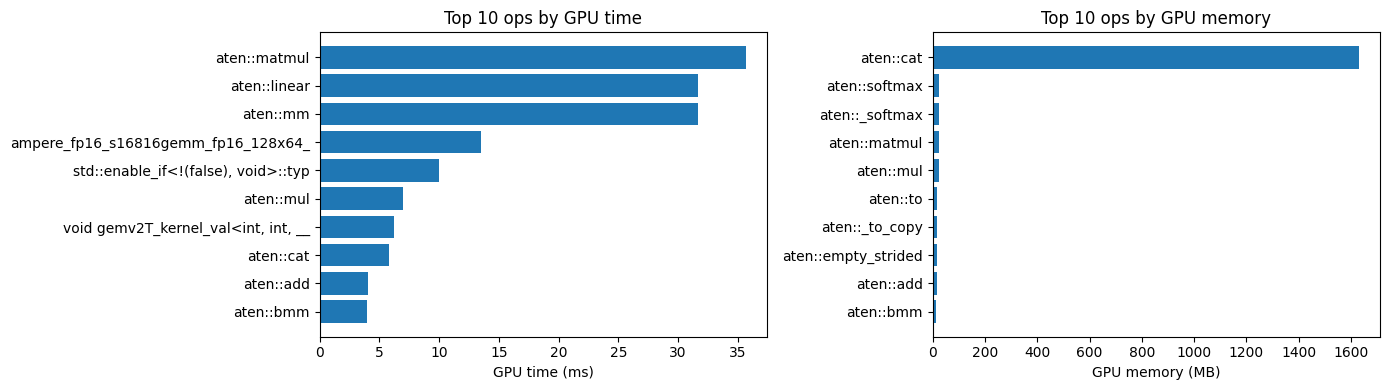


Saved -> results_per_op_profile.csv, hw1_per_op_profile.png


In [ ]:
PROF_MODEL_NAME = "SmolLM2-1.7B"
PROF_MODEL_ID = "HuggingFaceTB/SmolLM2-1.7B"
print(f"Loading {PROF_MODEL_NAME} for per-op profile...")
prof_tok = AutoTokenizer.from_pretrained(PROF_MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    PROF_MODEL_ID, torch_dtype=torch.float16, attn_implementation="eager",
).to(device).eval()

ids = prof_tok.encode(PROMPT_TEXT, return_tensors="pt")
mult = 1
while ids.shape[1] < PROMPT_LEN:
    mult += 1
    ids = prof_tok.encode(PROMPT_TEXT * mult, return_tensors="pt")
prompt_ids = ids[:, :PROMPT_LEN].to(device)

cache, last = prefill_full(model, prompt_ids)
tok = last.argmax(-1, keepdim=True)
for _ in range(3):  # warmup
    with torch.no_grad():
        out = model(tok, past_key_values=cache, use_cache=True)
    cache, tok = out.past_key_values, out.logits[:, -1].argmax(-1, keepdim=True)
torch.cuda.synchronize()

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA],
    record_shapes=True, profile_memory=True,
) as prof:
    for _ in range(8):
        with torch.no_grad():
            out = model(tok, past_key_values=cache, use_cache=True)
        cache, tok = out.past_key_values, out.logits[:, -1].argmax(-1, keepdim=True)
    torch.cuda.synchronize()

events = list(prof.key_averages())
top_time = sorted(events, key=gpu_time, reverse=True)[:10]
top_mem  = sorted(events, key=gpu_mem,  reverse=True)[:10]

print(f"\nPer-op profile for {PROF_MODEL_NAME} (8 decode steps):")
print("Top 10 ops by GPU time:")
for e in top_time:
    print(f"  {e.key[:50]:50s} | {gpu_time(e)/1000:7.2f} ms | calls={e.count}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh([e.key[:35] for e in top_time][::-1],
             [gpu_time(e) / 1000 for e in top_time][::-1])
axes[0].set(xlabel="GPU time (ms)", title="Top 10 ops by GPU time")
axes[1].barh([e.key[:35] for e in top_mem][::-1],
             [gpu_mem(e) / 1e6 for e in top_mem][::-1])
axes[1].set(xlabel="GPU memory (MB)", title="Top 10 ops by GPU memory")
plt.tight_layout(); plt.savefig("hw1_per_op_profile.png", dpi=100); plt.show()

pd.DataFrame([{
    "model": PROF_MODEL_NAME, "op": e.key[:60],
    "gpu_time_ms": round(gpu_time(e) / 1000, 3), "calls": e.count,
    "gpu_mem_MB": round(gpu_mem(e) / 1e6, 3),
} for e in top_time]).to_csv("results_per_op_profile.csv", index=False)

del model; torch.cuda.empty_cache()
print("\nSaved -> results_per_op_profile.csv, hw1_per_op_profile.png")


## 14. Unified Results

Aggregates the per-section CSVs into one comparison table.

In [ ]:
CSV_FILES = [
    "results_baseline.csv", "results_eviction.csv", "results_quality.csv",
    "results_quant_quality.csv", "results_quant_quality_L.csv",
    "results_gptq.csv", "results_composition.csv",
    "results_architecture_measured.csv", "results_fusion_analysis.csv",
    "results_fused_perf.csv", "results_triton_perf.csv",
    "results_per_op_profile.csv", "results_sweep.csv",
]
dfs = {f: pd.read_csv(f) for f in CSV_FILES if os.path.exists(f)}
for f in CSV_FILES:
    print(f"  {'OK' if f in dfs else 'missing':8s} | {f}")

def _need(df, csv_name, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  SKIP {csv_name}: missing columns {missing}")
        return False
    return True

unified_rows = []

if "results_composition.csv" in dfs:
    comp = dfs["results_composition.csv"]
    if _need(comp, "results_composition.csv",
             ["config","model","kivi_bits","cache_MB","compression","ppl"]):
        for _, r in comp.iterrows():
            if r["config"] == "baseline (full fp16)": cat = "baseline"
            elif "+" in r["config"]:                    cat = "composition (KIVI + eviction)"
            elif r["kivi_bits"] != 16:                   cat = "quantization (cache, KIVI)"
            else:                                         cat = "eviction"
            unified_rows.append({
                "category": cat, "model": r["model"], "policy": r["config"],
                "cache_MB": r["cache_MB"], "compression": r["compression"],
                "ppl": r["ppl"], "ratio_ppl": r.get("ratio_ppl"),
            })

if "results_architecture_measured.csv" in dfs:
    am = dfs["results_architecture_measured.csv"]
    if _need(am, "results_architecture_measured.csv",
             ["model","cache_MB","ppl","H_kv","G"]):
        am_clean = am[~am["collapsed"]] if "collapsed" in am.columns else am[am["ppl"] < 1e3]
        for mname in am_clean["model"].unique():
            msub = am_clean[am_clean["model"] == mname]
            base_cache = msub["cache_MB"].max()
            base_ppl = msub["ppl"].min()
            for _, r in msub.iterrows():
                if r["cache_MB"] == base_cache: continue
                unified_rows.append({
                    "category": "architectural (surgery)", "model": r["model"],
                    "policy": f"surgery H_kv={int(r['H_kv'])} (G={int(r['G'])})",
                    "cache_MB": float(r["cache_MB"]),
                    "compression": round(base_cache / r["cache_MB"], 2),
                    "ppl": float(r["ppl"]),
                    "ratio_ppl": round(r["ppl"] / base_ppl, 4),
                })

if "results_gptq.csv" in dfs:
    g = dfs["results_gptq.csv"]
    if _need(g, "results_gptq.csv",
             ["model","policy","ppl_fp16","ppl_gptq","compression_raw"]):
        for _, r in g.iterrows():
            unified_rows.append({
                "category": f"quantization (weights, {r.get('gpu','unknown GPU')})",
                "model": r["model"], "policy": str(r["policy"]),
                "cache_MB": None,
                "compression": float(r["compression_raw"]),
                "ppl": float(r["ppl_gptq"]),
                "ratio_ppl": round(float(r["ppl_gptq"]) / float(r["ppl_fp16"]), 4),
            })

df_unified = pd.DataFrame(unified_rows)
df_unified.to_csv("results_unified.csv", index=False)

def fmt(v, w, p=2):
    return "—".rjust(w) if v is None or pd.isna(v) else f"{v:>{w}.{p}f}"

for mname in sorted(df_unified["model"].unique()):
    print(f"\n=== {mname} ===")
    print(f"{'category':<32} {'policy':<32} {'cache_MB':>10} {'compr.':>7} {'ppl':>9} {'ratio':>7}")
    print("-" * 102)
    msub = df_unified[df_unified["model"] == mname].sort_values(
        ["category", "compression"], na_position="first")
    for _, r in msub.iterrows():
        print(f"{r['category']:<32} {str(r['policy'])[:32]:<32} "
              f"{fmt(r['cache_MB'],10,2)} {fmt(r['compression'],7,2)} "
              f"{fmt(r['ppl'],9,3)} {fmt(r['ratio_ppl'],7,3)}")
print(f"\nSaved -> results_unified.csv ({len(df_unified)} rows)")


  OK       | results_baseline.csv
  OK       | results_eviction.csv
  OK       | results_quality.csv
  OK       | results_quant_quality.csv
  OK       | results_quant_quality_L.csv
  OK       | results_gptq.csv
  OK       | results_composition.csv
  OK       | results_architecture_measured.csv
  OK       | results_fusion_analysis.csv
  OK       | results_fused_perf.csv
  OK       | results_triton_perf.csv
  OK       | results_per_op_profile.csv
  OK       | results_sweep.csv

=== Qwen2-0.5B ===
category                         policy                             cache_MB  compr.       ppl   ratio
------------------------------------------------------------------------------------------------------
baseline                         baseline (full fp16)                  12.58    1.00    11.179   1.000
composition (KIVI + eviction)    KIVI 8 + sliding                       1.85    6.78    66.634   5.961
composition (KIVI + eviction)    KIVI 8 + streaming                     1.85    6.78    

## 15. Sweep Visualization

cache / ppl / throughput vs sequence length, for each policy on each model.

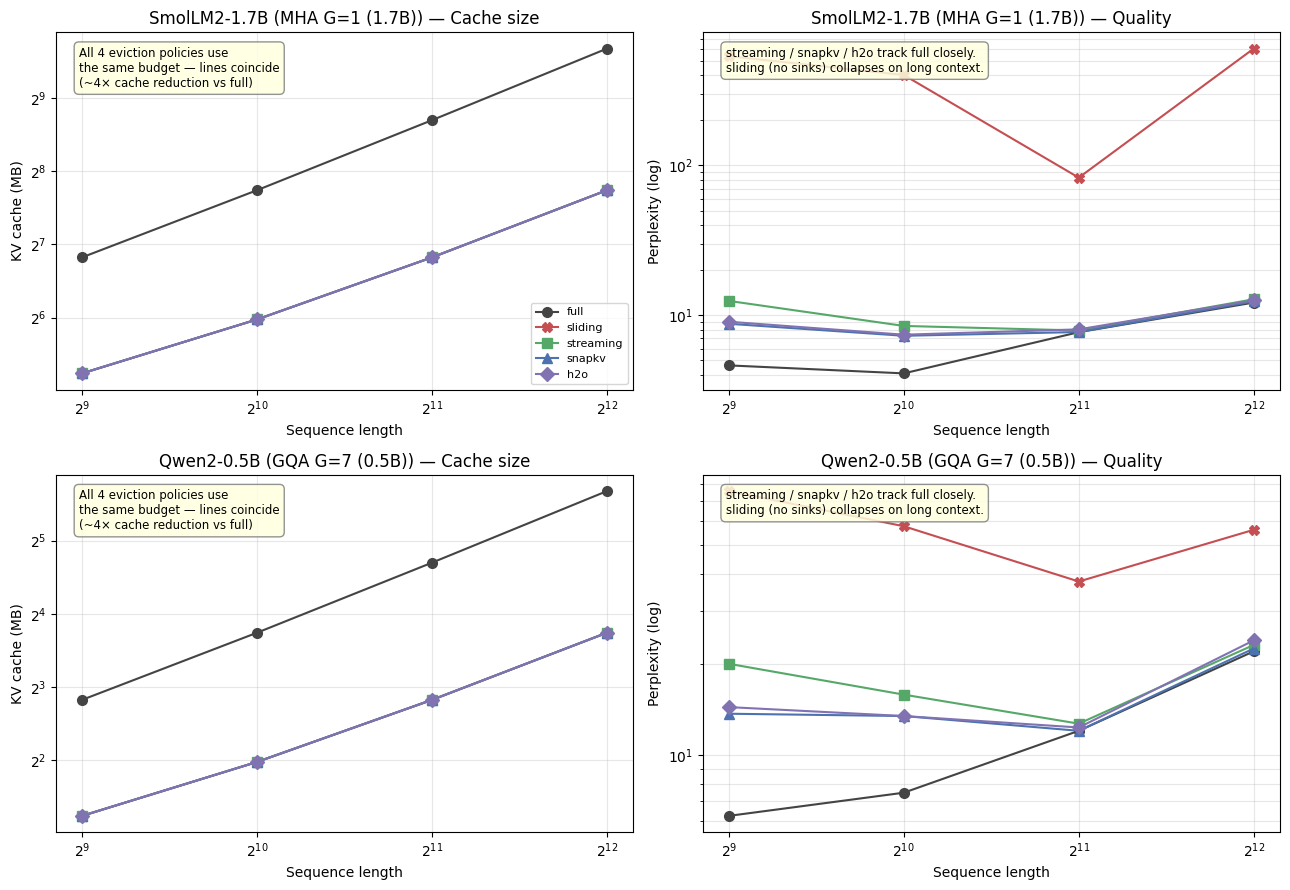

Saved -> results_sweep.png (2 models)


In [ ]:
sw = pd.read_csv("results_sweep.csv")
models_present = sw["model"].unique()
n_models = len(models_present)

fig, axes = plt.subplots(n_models, 2, figsize=(13, 4.5 * n_models))
if n_models == 1: axes = axes.reshape(1, -1)

colors_p  = {"full": "#444", "sliding": "#C44E52", "streaming": "#55A868",
             "snapkv": "#4C72B0", "h2o": "#8172B2"}
markers_p = {"full": "o", "sliding": "X", "streaming": "s",
             "snapkv": "^", "h2o": "D"}

for row_idx, mname in enumerate(models_present):
    msub = sw[sw["model"] == mname]
    title_arch = msub["arch"].iloc[0] if len(msub) else ""

    # Left: cache MB (log–log)
    ax = axes[row_idx, 0]
    for pol in ["full", "sliding", "streaming", "snapkv", "h2o"]:
        psub = msub[msub["policy"].str.startswith(pol)].sort_values("seq_len")
        if len(psub) == 0: continue
        ax.plot(psub["seq_len"], psub["cache_MB"],
                color=colors_p[pol], marker=markers_p[pol], markersize=7,
                linewidth=1.5, label=pol)
    ax.set(xlabel="Sequence length", ylabel="KV cache (MB)",
           title=f"{mname} ({title_arch}) — Cache size")
    ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
    ax.grid(True, which="both", alpha=0.3)
    ax.text(0.04, 0.96,
            "All 4 eviction policies use\nthe same budget — lines coincide\n(~4× cache reduction vs full)",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray", alpha=0.85))
    if row_idx == 0: ax.legend(fontsize=8, loc="lower right")

    # Right: perplexity (log y)
    ax = axes[row_idx, 1]
    for pol in ["full", "sliding", "streaming", "snapkv", "h2o"]:
        psub = msub[msub["policy"].str.startswith(pol)].dropna(subset=["ppl"]).sort_values("seq_len")
        if len(psub) == 0: continue
        ax.plot(psub["seq_len"], psub["ppl"],
                color=colors_p[pol], marker=markers_p[pol], markersize=7,
                linewidth=1.5, label=pol)
    ax.set(xlabel="Sequence length", ylabel="Perplexity (log)",
           title=f"{mname} ({title_arch}) — Quality")
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.text(0.04, 0.96,
            "streaming / snapkv / h2o track full closely.\nsliding (no sinks) collapses on long context.",
            transform=ax.transAxes, fontsize=8.5, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray", alpha=0.85))

plt.tight_layout()
plt.savefig("results_sweep.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Saved -> results_sweep.png ({n_models} models)")

## 16. Pareto Frontier

Unifies §10 composition (KIVI x eviction) with §11b architecture (surgery)
on the same compression vs ppl-ratio axes. The Pareto frontier marks
which configurations are not dominated by any other point.

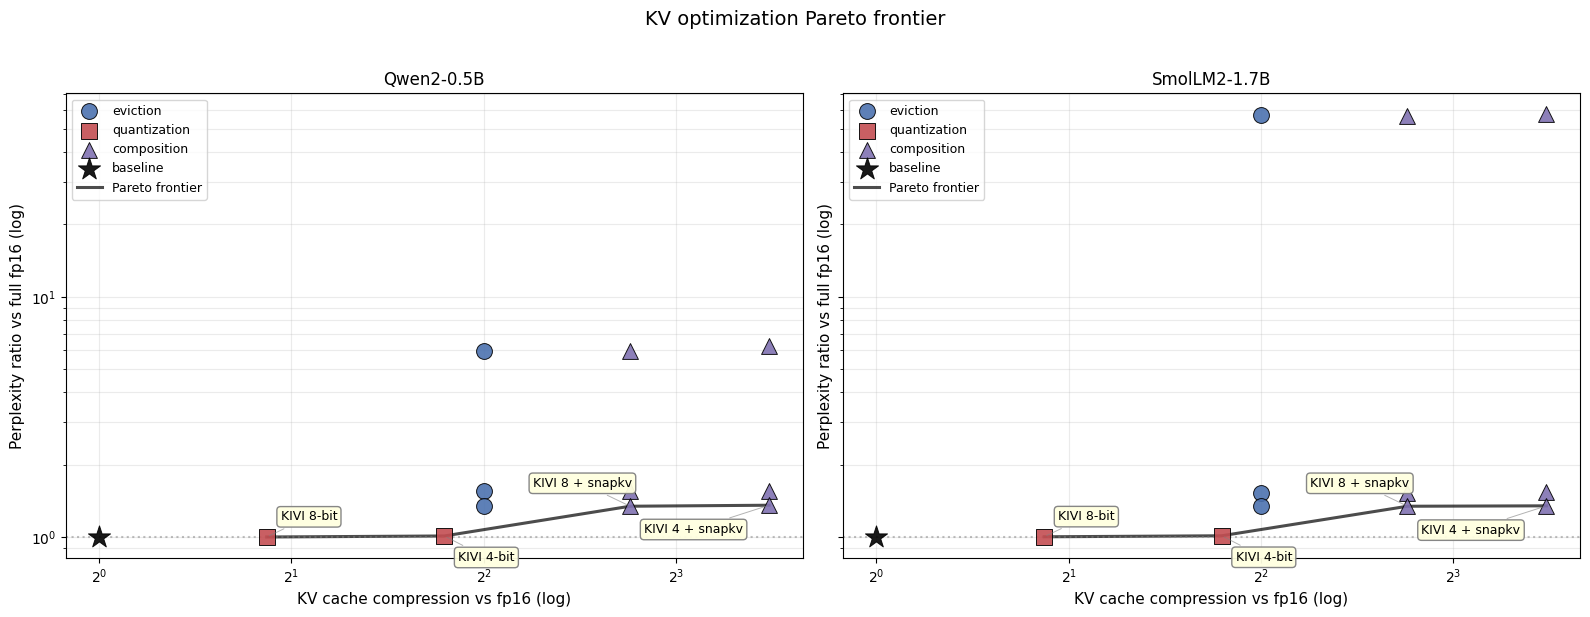


Pareto-optimal (8 rows):
       model           label    technique  compression  ratio_ppl
  Qwen2-0.5B      KIVI 8-bit quantization         1.83     0.9980
  Qwen2-0.5B      KIVI 4-bit quantization         3.47     1.0079
  Qwen2-0.5B KIVI 8 + snapkv  composition         6.78     1.3405
  Qwen2-0.5B KIVI 4 + snapkv  composition        11.19     1.3536
SmolLM2-1.7B      KIVI 8-bit quantization         1.83     1.0000
SmolLM2-1.7B      KIVI 4-bit quantization         3.47     1.0098
SmolLM2-1.7B KIVI 8 + snapkv  composition         6.78     1.3404
SmolLM2-1.7B KIVI 4 + snapkv  composition        11.19     1.3456


In [ ]:
comp = pd.read_csv("results_composition.csv")

pts = []
for _, r in comp.iterrows():
    if pd.isna(r.get("ratio_ppl")): continue
    if r["config"] == "baseline (full fp16)":       tech = "baseline"
    elif "+" in r["config"]:                         tech = "composition"
    elif r["kivi_bits"] != 16:                       tech = "quantization"
    else:                                            tech = "eviction"
    pts.append({"model": r["model"], "label": r["config"], "technique": tech,
                "compression": float(r["compression"]),
                "ratio_ppl": float(r["ratio_ppl"])})

df_all = pd.DataFrame(pts)

def pareto_mask(df):
    keep = []
    for i, r in df.iterrows():
        dom = ((df["compression"] >= r["compression"]) &
               (df["ratio_ppl"]   <= r["ratio_ppl"])   &
               ((df["compression"] > r["compression"]) |
                (df["ratio_ppl"]   < r["ratio_ppl"])))
        keep.append(not dom.any())
    return keep

df_all["pareto"] = False
for m in df_all["model"].unique():
    sub_mask = df_all["model"] == m
    df_all.loc[sub_mask, "pareto"] = pareto_mask(df_all[sub_mask])

models = sorted(df_all["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(8 * len(models), 6), sharey=True)
if len(models) == 1: axes = [axes]

tech_colors  = {"baseline":"#000", "eviction":"#4C72B0",
                "quantization":"#C44E52", "composition":"#8172B2"}
tech_markers = {"baseline":"*", "eviction":"o", "quantization":"s", "composition":"^"}

for ax, m in zip(axes, models):
    sub = df_all[df_all["model"] == m]

    for tech in ["eviction", "quantization", "composition", "baseline"]:
        psub = sub[sub["technique"] == tech]
        if len(psub) == 0: continue
        size = 280 if tech == "baseline" else 130
        ax.scatter(psub["compression"], psub["ratio_ppl"],
                   c=tech_colors[tech], marker=tech_markers[tech],
                   s=size, edgecolors="black", linewidths=0.7,
                   label=tech, zorder=3, alpha=0.9)

    pareto_pts = sub[sub["pareto"]].sort_values("compression")
    if len(pareto_pts) > 1:
        ax.plot(pareto_pts["compression"], pareto_pts["ratio_ppl"],
                color="black", linewidth=2.2, alpha=0.7, zorder=2,
                label="Pareto frontier")

    offsets = [(10, 12), (10, -18), (-70, 14), (-90, -20)]
    for i, (_, r) in enumerate(pareto_pts.iterrows()):
        if r["technique"] == "baseline": continue
        off = offsets[i % len(offsets)]
        ax.annotate(r["label"], (r["compression"], r["ratio_ppl"]),
                    fontsize=9, xytext=off, textcoords="offset points",
                    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6, lw=0.7),
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow",
                              ec="gray", alpha=0.95))

    ax.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xlabel("KV cache compression vs fp16 (log)", fontsize=11)
    ax.set_ylabel("Perplexity ratio vs full fp16 (log)", fontsize=11)
    ax.set_title(m, fontsize=12)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=9, loc="upper left")

plt.suptitle("KV optimization Pareto frontier", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results_pareto.png", dpi=140, bbox_inches="tight")
plt.show()

df_pareto = df_all[df_all["pareto"]].sort_values(["model", "compression"]).reset_index(drop=True)
df_pareto.to_csv("results_pareto.csv", index=False)
print(f"\nPareto-optimal ({len(df_pareto)} rows):")
print(df_pareto[["model","label","technique","compression","ratio_ppl"]].to_string(index=False))

## 17. Limitations & Conclusion

**Hardware-bandwidth dependence.** All throughput numbers are from a
Colab A100. KV-cache optimizations attack a memory-bandwidth bottleneck,
so the *qualitative* picture (eviction dominated by quantization,
compositions extend the frontier, fusion saves an HBM round-trip) holds
across hardware. The *absolute* tok/s and ms numbers will not carry over
to consumer cards with lower HBM bandwidth — the relative gain from
fusion typically grows on bandwidth-constrained hardware.

**Kernel microbenchmark, not end-to-end.** The Triton kernel sections
(§5, §12) measure the kernel in isolation on synthetic Q/K/V tensors,
not inside a HuggingFace attention module or `model.generate()` loop.
End-to-end integration is left as future work.

**Batch=1 overhead floor.** Sections 4/6/7 throughput numbers are noisy
near the bottom because Python `generate()` loop overhead dominates GPU
compute at batch=1 with short decodes. Treat these as differential
measurements vs the §4 baseline, not absolute speedups.

**One-shot pruning.** SnapKV and H2O here use the one-shot/static
variant — pruning happens once after prefill, not re-evaluated each
decode step. Dynamic variants would tighten quality slightly at the
cost of per-step scoring overhead.

## 18. Findings

### Summary table

| Technique                   | Compression | Quality cost              | Best use case                          |
|----------------------------|-------------|---------------------------|----------------------------------------|
| KIVI 8-bit (quantization)  | 1.83×       | ~0% (essentially free)    | General inference — safe default       |
| KIVI 4-bit (quantization)  | 3.47×       | ~1% perplexity            | Memory-constrained inference           |
| Sliding window alone       | 4×          | 50×+ at L=4096 (collapses)| Avoid without sink tokens              |
| StreamingLLM (sink+window) | 4×          | ~50% perplexity           | Long context without retraining        |
| SnapKV / H2O eviction      | 4×          | ~35% perplexity           | When quantization is not an option     |
| KIVI 4 + SnapKV            | 11.2×       | ~35% perplexity           | Maximum compression on this sweep      |
| Fused SWA + int8 dequant   | —           | None (max-error 0.001)    | Kernel-level memory-traffic reduction  |

### Key findings

**Best memory reduction at near-zero quality cost.** KIVI 4-bit
quantization delivers 3.47× KV cache compression with perplexity within
1% of fp16 baseline on both SmolLM2-1.7B (MHA) and Qwen2-0.5B (GQA).

**Quantization and composition dominate the Pareto frontier.** Pure
eviction policies (sliding, streaming, snapkv, h2o) never appear on the
frontier — at every compression level, quantization or
quantization+eviction composition achieves lower perplexity.
Compositions extend the frontier to 11.2× compression at ~35%
perplexity increase.

**Triton fused kernel.** The fused sliding-window + int8 dequant kernel
saves the HBM round-trip of dequantized fp16 K/V vs the two-kernel
reference path, with correctness verified to max-error 0.001 vs
PyTorch dequant + Triton attention.

### Failure cases observed

**Sliding window without sinks collapses.** Perplexity rises 50×+ at
L=4096 on SmolLM2. StreamingLLM (sliding + sink) recovers most of the
loss, confirming attention sinks are necessary for sliding window to
be viable as a standalone policy.

**Architectural surgery does not work as a cheap optimization.** Of 8
inference-time GQA-conversion configurations tested, 6 collapsed to
infinite perplexity; the 2 that did not collapse provided no cache
reduction. Architectural compression requires retraining.

### Practical recommendation

Start with KIVI 4-bit (near-free 3.5× compression). If more compression
is needed, add SnapKV on top, accepting ~35% perplexity increase. Avoid
pure eviction; avoid inference-time architectural surgery.

In [ ]:
!zip kvscope_outputs.zip results_*.csv *.png kernels.py benchmark_utils.py policies.py quantization.py analysis.ipynb

	zip warning: name not matched: analysis.ipynb
  adding: results_architecture.csv (deflated 25%)
  adding: results_architecture_measured.csv (deflated 60%)
  adding: results_baseline.csv (deflated 44%)
  adding: results_composition.csv (deflated 68%)
  adding: results_eviction.csv (deflated 58%)
  adding: results_fused_perf.csv (deflated 47%)
  adding: results_fusion_analysis.csv (deflated 35%)
  adding: results_gptq.csv (deflated 36%)
  adding: results_pareto.csv (deflated 62%)
  adding: results_per_op_profile.csv (deflated 47%)
  adding: results_quality.csv (deflated 55%)
  adding: results_quant_quality.csv (deflated 67%)
  adding: results_quant_quality_L.csv (deflated 66%)
  adding: results_sweep.csv (deflated 70%)
  adding: results_triton_perf.csv (deflated 48%)
  adding: results_unified.csv (deflated 71%)
  adding: hw1_per_op_profile.png (deflated 18%)
  adding: results_pareto.png (deflated 15%)
  adding: results_sweep.png (deflated 7%)
  adding: kernels.py (deflated 76%)
  adding